# 🎯 Chapter 5: Classification
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Topik:** Naive Bayes, Logistic Regression, Evaluation Metrics, dan Imbalanced Data
---
## 1. Pendahuluan
Klasifikasi adalah proses memprediksi label kategori. Bab ini membahas algoritma statistik untuk klasifikasi serta bagaimana cara mengevaluasi performa model melampaui sekadar akurasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

%matplotlib inline
np.random.seed(42)

## 2. Naive Bayes
Naive Bayes bekerja sangat baik untuk klasifikasi awal. Ia menghitung probabilitas tiap fitur terhadap kelas target secara independen.

In [2]:
# Simulasi data sederhana (fitur numerik untuk memprediksi kategori)
X, y = np.random.randn(200, 2), np.random.choice([0, 1], 200)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print(f"Akurasi Naive Bayes: {nb_model.score(X_test, y_test):.2f}")

Akurasi Naive Bayes: 0.53


## 3. Logistic Regression
Berbeda dengan regresi linear, regresi logistik menghasilkan probabilitas menggunakan fungsi sigmoid.

In [3]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Melihat probabilitas untuk 5 data pertama
probs = log_model.predict_proba(X_test)[:5]
print("Probabilitas [Kelas 0, Kelas 1]:\n", probs)

Probabilitas [Kelas 0, Kelas 1]:
 [[0.47900275 0.52099725]
 [0.57010442 0.42989558]
 [0.57499101 0.42500899]
 [0.48547571 0.51452429]
 [0.48599703 0.51400297]]


## 4. Evaluasi Model: Confusion Matrix
Confusion Matrix membantu kita melihat di mana model membuat kesalahan: apakah menebak positif padahal negatif (False Positive) atau sebaliknya.

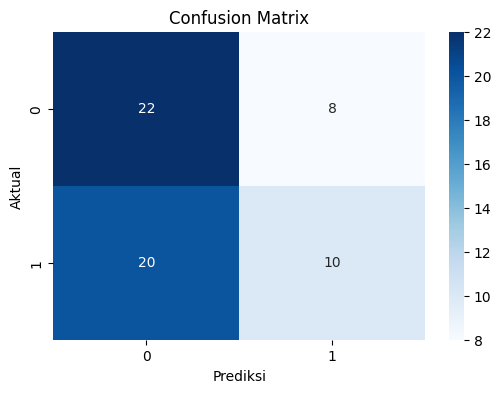


Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.73      0.61        30
           1       0.56      0.33      0.42        30

    accuracy                           0.53        60
   macro avg       0.54      0.53      0.51        60
weighted avg       0.54      0.53      0.51        60



In [4]:
y_pred = log_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 5. ROC Curve dan AUC
ROC Curve memplot tingkat True Positive terhadap False Positive. Luas di bawah kurva (AUC) adalah ukuran kemampuan model dalam membedakan kelas.

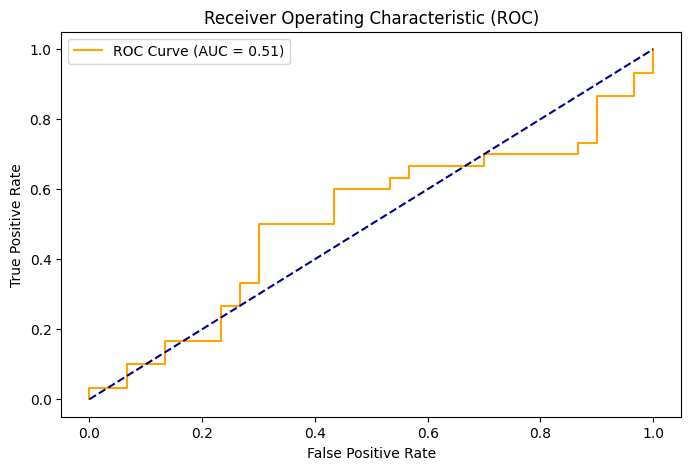

In [5]:
y_probs = log_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()

## 6. Menangani Data Tidak Seimbang (Imbalanced Data)
Jika data didominasi satu kelas, akurasi akan terlihat sangat tinggi padahal model gagal mendeteksi kelas minoritas. Salah satu cara sederhana adalah mengubah bobot kelas pada model.

In [6]:
# Model dengan penyeimbangan bobot otomatis
balanced_model = LogisticRegression(class_weight='balanced')
balanced_model.fit(X_train, y_train)
print("Model telah dilatih dengan parameter class_weight='balanced'.")

Model telah dilatih dengan parameter class_weight='balanced'.
